<a href="https://colab.research.google.com/github/oviccenzo/CienciaDeDados/blob/python/Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [431]:
%%capture
!pip install jupyterthemes

In [432]:
import numpy as np
import matplotlib.pyplot as plt
from jupyterthemes import jtplot
jtplot.style()

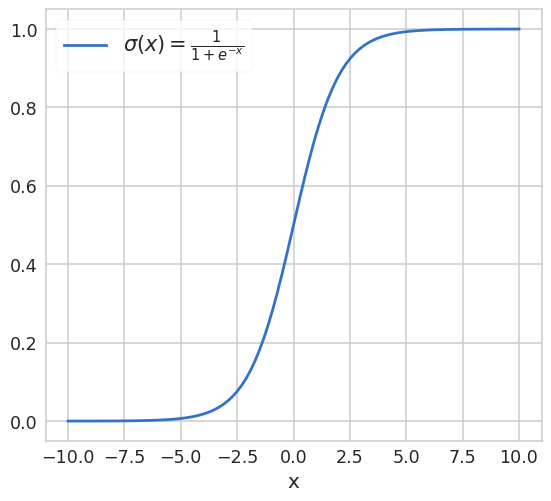

In [433]:
X = np.linspace(-10,10,100)
sig = 1/(1 + np.exp(-X))
plt.plot(X, sig, '-b', linewidth = 2, label=r"$\sigma(x) = \frac{1}{1 + e^{-x}}$")
plt.xlabel("x")
plt.legend(loc="upper left", fontsize=15)
plt.show()


In [434]:
def logistc(x):
  return 1 / (1 + np.exp(-x))

In [435]:
logistc(-10 + (10 * 1) + (12 * 1) + (8 * 1))

np.float64(0.9999999979388463)

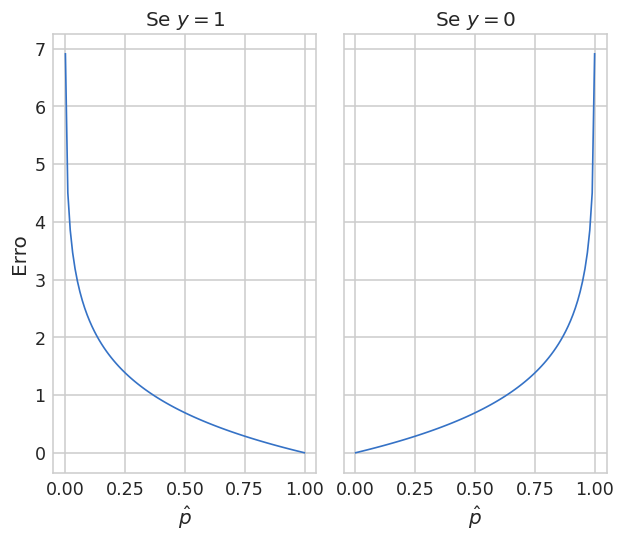

In [436]:
fig, ax = plt.subplots(1,2,sharey=True)
x = np.linspace(0.001, 0.999,100) #evitar erros pq log(0) é inf e log(1) é 0

ax[0].plot(x, -np.log(x))
ax[0].set_title('Se $y = 1$')
ax[0].set_xlabel('$\hat{p}$')
ax[0].set_ylabel('Erro')

ax[1].plot(x, -np.log(1 - x))
ax[1].set_title('Se $y = 0$')
ax[1].set_xlabel('$\hat{p}$')

plt.tight_layout()
plt.show()

Exemplo com o dataset Titanic

In [437]:
import seaborn as sns
import pandas as pd

In [438]:
titanic = sns.load_dataset('titanic')

In [439]:
feature_names = ['pclass','female','age','fare' ]
titanic['female'] = titanic['sex'].map({"male" : 0, "female" : 1})
titanic.dropna(subset=feature_names, inplace=True)

In [440]:
X

array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
         2.12121212,   2.32323232,   2.52525253,   2.72

In [441]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,female
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


In [442]:
y = titanic['survived'].values
X = titanic[feature_names].values

In [443]:
y #series da coluna survived

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,

In [444]:
print('Nomes dos Atributos: ', feature_names, '\n')
print('Tamanho de X: ', X.shape, '\n')
print('Tamanho de y: ', y.shape, '\n')

Nomes dos Atributos:  ['pclass', 'female', 'age', 'fare'] 

Tamanho de X:  (714, 4) 

Tamanho de y:  (714,) 



In [445]:
y = titanic['survived'].values
X = titanic[feature_names].values

In [446]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=123)

In [447]:
print('Tamanho de X_train: ', X_train.shape, '\n')
print('Tamanho de X_test: ', X_test.shape, '\n')
print('Tamanho de y_train: ', y_train.shape, '\n')
print('Tamanho de y_test: ', y_test.shape, '\n')

Tamanho de X_train:  (535, 4) 

Tamanho de X_test:  (179, 4) 

Tamanho de y_train:  (535,) 

Tamanho de y_test:  (179,) 



In [448]:
from sklearn.linear_model import LogisticRegression

In [449]:
clf = LogisticRegression(random_state=123)

In [450]:
clf.fit(X_train, y_train)

LogisticRegression(random_state=123)

In [451]:
#coeficiente do modelo
for feature, coef in zip(feature_names, clf.coef_[0].tolist()):
  print(f'{feature}: {round(coef, 3)}')

#Constante do modelo
print(f"Constante {round(clf.intercept_[0],3)}")

pclass: -1.11
female: 2.477
age: -0.028
fare: 0.002
Constante 1.828


In [452]:
#caso de um mulher na 3 classe com idade 33 e pegou £0.5
# 0_0 + 0_1 * x_1 + 0_2 * x_2 + 0_3 * x_3 + 0_4 * x_4
logistc(1.828 + (-1.11 * 3) + (2.477 * 1) + (-0.028 * 33) + (0.5 * 0.002))

np.float64(0.5129970714585417)

In [453]:
logistc(1.828 + (-1.11 * 3) + (2.477 * 0) + (-0.028 * 50) + (2 * 0.002))

np.float64(0.05225251881725587)

Acuracia do modelo

In [454]:
from sklearn.metrics import accuracy_score

In [455]:
y_test = y_train
y_train_pred = clf.predict(X_train)
y_test_true = y_test
y_test_pred = clf.predict(X_test)
